# Solution: Convolutions and Pooling

## Introduction

In this notebook, we will explore the concepts of *convolution* and *pooling* in deep learning.

We will start by manually implementing these operations to gain a deeper understanding of how they work.
Later, we will use PyTorch's built-in modules to see the advantages of using such libraries.

This is an interactive notebook, so download it and play with the widgets.

You also have an exercise at the end of the notebook!

## Libraries

Let's begin by importing the necessary libraries.

We'll need NumPy for numerical operations, PyTorch for deep learning operations, and Matplotlib for visualization.
Furthermore, we'll need PIL for visualizing images and tkinter to be able to select images.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image

import ipywidgets as widgets
from ipywidgets.widgets import VBox, HBox
from IPython.display import display, clear_output

from cycler import cycler
import seaborn as sns

# Set the color scheme
sns.set_theme()
colors = ['#0076C2', '#EC6842', '#A50034', '#009B77', '#FFB81C', '#E03C31', '#6CC24A', '#EF60A3', '#0C2340', '#00B8C8', '#6F1D77']
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
plt.rcParams.update({'font.size': 12})

## Let's use a sample Image

Load a sample image that will be used throughout the notebook.
You can use any image you prefer or the one we propose.

In [5]:
!wget "https://surfdrive.surf.nl/files/index.php/s/juMBtfwZzwkK8F7/download" -O cracks.jfif

--2024-12-08 17:15:20--  https://surfdrive.surf.nl/files/index.php/s/juMBtfwZzwkK8F7/download
Resolving surfdrive.surf.nl (surfdrive.surf.nl)... 145.107.8.140, 145.107.56.140, 2001:610:10b:2:0:a11:da7a:5afe, ...
Connecting to surfdrive.surf.nl (surfdrive.surf.nl)|145.107.8.140|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8220 (8.0K) [application/octet-stream]
Saving to: ‘cracks.jfif’

cracks.jfif         100%[===================>]   8.03K  --.-KB/s    in 0s      

2024-12-08 17:15:21 (121 MB/s) - ‘cracks.jfif’ saved [8220/8220]



In [6]:
!ls

cracks.jfif  sample_data


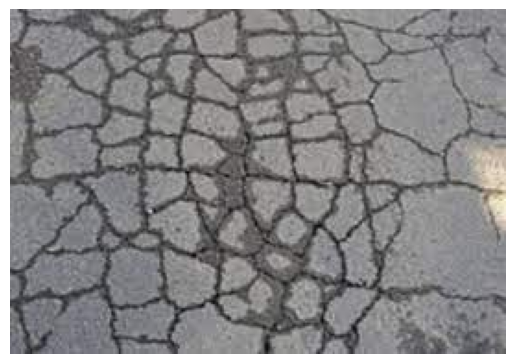

In [7]:
# Load the sample image and normalize it
sample_image = Image.open("cracks.jfif")

sample_image = np.array(sample_image)/255 # Normalize range of values to [0,1]

plt.imshow(sample_image)
plt.axis('off');

## Convolution Operation

What is convolution?

Convolution is an operation in which a kernel (or filter) matrix, in blue, slides over an input image and is pointwise multiplied by the entries of the kernel with the overlapping values in the input image.
The sum of these values corresponds to the respective entry in the output matrix Y.

<img src="../../figures/copyrighted/convolution_kernel.png" width="800" float="center"/>

In mathematical terms, we can write the convolution of an input matrix $A \in \mathbb{R}^{S \times T}$ by a kernel matrix $K \in \mathbb{R}^{M \times N}$ as:
$$
(A * K)_{s,t} = \sum_{m=1}^{M} \sum_{n=1}^{N} A_{m,n} \cdot K_{s - m, t - n}
$$
where M and N are the height and width of the kernel.

### Manual implementation

Here we implement a function to manually perform the convolution operation, following the previous equation.

Then, we use a simple 3x3 kernel as an example.

In [ ]:
# Manual Implementation of Convolution Operation
def manual_convolution(image, kernel):
    height, width, channels = image.shape
    kernel_size = kernel.shape[0]

    # we assume here that there is no padding
    feature_map = np.zeros((height - kernel_size + 1, width - kernel_size + 1, channels))

    for k in range(channels):
        for i in range(height - kernel_size + 1):
            for j in range(width - kernel_size + 1):
                patch = image[i:i+kernel_size, j:j+kernel_size]
                feature_map[i, j, k] = np.sum(patch * kernel)

    return feature_map.sum(-1) # summing over the channels

In [9]:
# Define a simple 3x3 kernel
# The following kernel is called vertical Sobel operator and can be used to detect vertical edges
kernel = np.array([[-1, -2, -1],
                   [0, 0, 0],
                   [1, 2, 1]])

# Perform manual convolution
feature_map_manual = manual_convolution(sample_image, kernel)

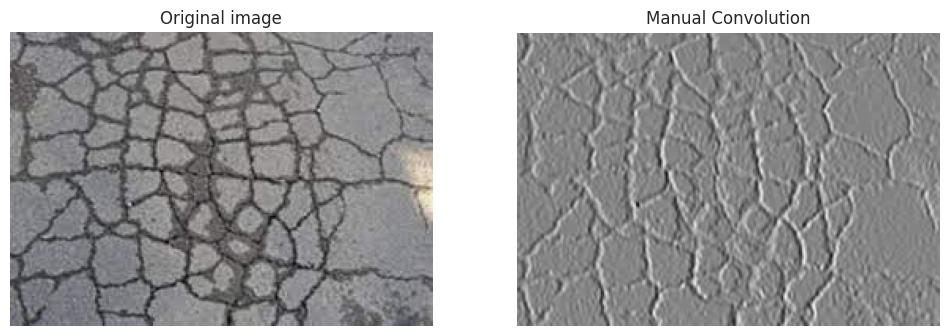

In [10]:
# Compare and visualize the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original image")
plt.imshow(sample_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Manual Convolution")
plt.imshow(feature_map_manual, cmap='gray')
plt.axis('off')

plt.show()

### Pytorch implementation

Our manual implementation works, but for large images it's not efficient (because of the for loops).
We can equivalently use PyTorch's built-in convolutional layer (**nn.Conv2d**) to perform the convolution operation on the same sample image.

In [11]:
# Convert the image to a PyTorch tensor
sample_image_tensor = torch.Tensor(sample_image).permute(2, 0, 1).unsqueeze(0)

# Create a convolutional layer
conv_layer = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3,
                       stride=1, padding=0, bias=False)

conv_layer.weight = nn.Parameter(torch.FloatTensor(np.array([[kernel.T, kernel.T, kernel.T]])))

# Perform convolution using PyTorch
output = conv_layer(sample_image_tensor).detach()

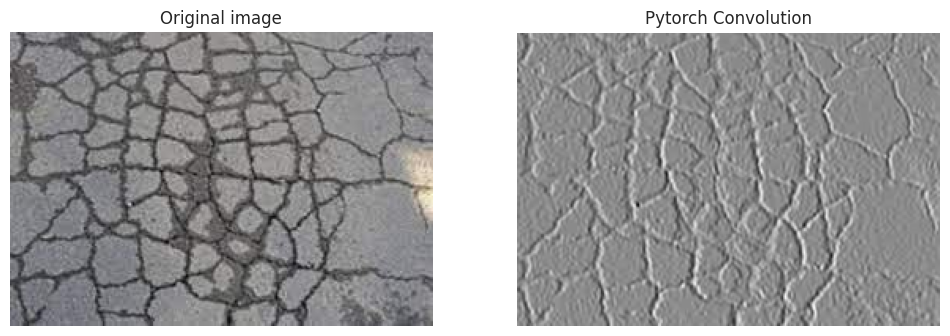

In [12]:
# Compare and visualize the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original image")
plt.imshow(sample_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Pytorch Convolution")
plt.imshow(output[0, 0], cmap='gray')
plt.axis('off')

plt.show()

### [OPTIONAL] Try out different kernels

Search [online](https://medium.com/@nikatsanka/comparing-edge-detection-methods-638a2919476e), ask ChatGPT or Gemini for other important **kernels**. Try to implement them by changing the element of your kernel array.

## Pooling Operation

### Manual implementation

Implement a function to manually perform max pooling operation.
You can take inspiration from the manual implementation of the convolutional kernel from before.
Now, instead of pointwise multiplying the image patch by a kernel, you are extract the maximum (or average) value from the patch.


```{figure} ../../figures/copyrighted/max_pooling.svg
:scale: 18%
:name: max_pooling

Illustration for Maximum Pooling. From Prince, Simon JD. Understanding deep learning. MIT
```



In [15]:
# Manual Implementation of Pooling Operation (Max-Pooling)
def manual_max_pooling(image, pool_size):
    height, width, channels = image.shape
    pooled_height = height // pool_size
    pooled_width = width // pool_size
    pooled_image = np.zeros((channels, pooled_height, pooled_width))

    # ---------------------- student exercise --------------------------------- #
    for k in range(channels):
        for i in range(pooled_height):
            for j in range(pooled_width):
                patch = image[i*pool_size:i*pool_size+pool_size, j*pool_size:j*pool_size+pool_size, k]
                pooled_image[k, i, j] = np.max(patch) # You can change the opartion here to obtain average pooling as well
    # ---------------------- student exercise --------------------------------- #

    return pooled_image

# Perform manual max-pooling
pool_size = 2
pooled_image_manual = manual_max_pooling(sample_image, pool_size)

### Pytorch implementation

Use PyTorch's nn.MaxPool2d or nn.AvgPool2d to perform the pooling operation on the feature maps obtained in the previous sections.

In [16]:
sample_image_tensor = torch.Tensor(sample_image).permute(2, 0, 1)

# Create a pooling layer
pool_layer = nn.MaxPool2d(kernel_size=pool_size)

# Perform pooling using PyTorch
pooled_output = pool_layer(sample_image_tensor).detach()

In [17]:
assert np.isclose(pooled_image_manual, pooled_output.numpy()).all(), "Your implementation is not correct"

### Comparison

Compare the pooled feature maps obtained from the manual implementation and the built-in module, similar to the comparison for convolution.


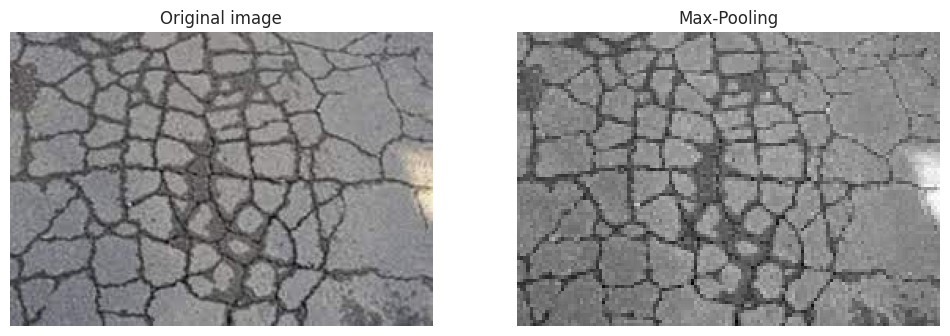

In [18]:
# Compare and visualize the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original image")
plt.imshow(sample_image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Max-Pooling")
plt.imshow(pooled_output[0], cmap='gray')
plt.axis('off')

plt.show()

## Concluding Remarks

In this notebook, we implemented convolution and analysed how different kernels affect the convolution operator.
We also implemented pooling operations both manually and using PyTorch's built-in modules.

Now you can start using these module, with the understanding of what they do, in the development of your own CNN.